### Business Understanding

Business Understanding:

This notebook is aimed for streaming services to help predict movie quality categories in order to know which movies are worth streaming, more precisely content acquisition teams at streaming platforms deciding whether to license third-party movies. The model supports a threshold-based acquisition decision through direct classification, not general score prediction.

Based on the prediction from the supervised classification model and budget constraints, the acquisition team will work on buying a certain movie if it is classified as meeting the acquisition bar.

Metacritic score, binarized (or banded), is going to be the basis for our target variable since it is a proxy for how well the movie will be perceived and how much it will be profitable. Rather than predicting the exact score, the model predicts whether a movie clears a quality threshold (Metacritic ≥ 70), directly framing the business decision as a classification problem.

Underestimating a high-quality movie (a false negative) leads to irreversible opportunity loss, while overestimating a low-quality movie (a false positive) results in limited downside due to user choice and portfolio diversification.

The most dangerous failure mode is a high-confidence false negative: a movie that is clearly above the acquisition bar being classified as "reject." This risk is asymmetric: missing a successful movie is more costly than acquiring a mediocre one. Therefore, misclassifications far from the decision boundary (e.g., a strong hit predicted as a clear reject) are catastrophic, while boundary-adjacent misclassifications are not. This asymmetry should be encoded through cost-sensitive threshold tuning on predicted probabilities and asymmetric evaluation metrics, rather than raw classification accuracy.

Given the asymmetric cost of false negatives, conservatism in predictions is corrected at the decision stage by lowering the probability threshold used to classify a movie as "acquire," based on validation-set decision error analysis, rather than embedding asymmetry directly into the training loss.

Methodology:

Given fixed budget and attention constraints, the acquisition decision is formulated as a ranking problem over predicted class probabilities, where only the top-K movies by predicted probability of exceeding the quality bar are selected, rather than applying a fixed hard classification cutoff alone.

Licensing fees, marketing allocation, and expected profitability increase monotonically with predicted quality band, making fine-grained ordering among acquired movies economically meaningful even after moving to a classification framing.

Movies are labeled using a minimum quality threshold (Metacritic ≥ 70) as the primary binary target. As a refinement, movies are additionally grouped into ordered quality bands of practical relevance (e.g., Reject <70, Standard 70–84, Premium 85+), modeled as an ordinal classification target, within which small differences in underlying score (≈1–2 points) are considered economically negligible and are not distinguished by the model.

Limitations:

Critics ≠ viewers

Classification label ≠ watch time

Classification label ≠ retention

Classification label ≠ revenue

The model is intended to classify and rank relative quality among candidate movies, not estimate absolute profitability.

Metacritic-derived class labels are used as an imperfect proxy for expected content quality due to lack of direct profitability or engagement data.

Budget constraints are applied after classification/ranking, not during model training.

Binarizing or banding a continuous score discards information near the decision boundary: movies with very similar true quality (e.g., 68 vs. 71) can receive opposite labels, inflating apparent misclassification cost unless boundary-adjacent errors are evaluated separately from far-boundary errors.

Class imbalance is likely (acquisition-worthy movies may be a minority class), so accuracy is a misleading metric; precision, recall, PR-AUC, and cost-weighted metrics at the decision threshold should be prioritized over raw accuracy.

Ranking reliability from predicted probabilities decreases near the decision boundary and at extreme quality levels due to score compression and critic variance, limiting confidence in fine-grained ordering among top-tier movies.

We are implicitly assuming:

Movies are evaluated before release

Features are known pre-acquisition

Quality class/band is predictable from metadata

Any post-release or popularity-derived features will be excluded to prevent leakage.

### Libraries



In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chisquare
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from collections import Counter
from sklearn.impute import KNNImputer
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import LabelEncoder  
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
import wn
from sklearn.dummy import DummyClassifier
from category_encoders import TargetEncoder  

### Data Understanding


In [117]:
df = pd.read_csv('metacritic_movies.csv')

In [118]:
df.head()

,id,title,releaseDate,rating,genres,description,duration,tagline,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,production_companies,director,writer,top_cast
0,2000545497,Dekalog (1988),3/22/1996,TV-MA,Drama,This masterwork by Krzysztof Kieślowski is one...,572,NaN,100.0,13,Universal acclaim,75.0,224.0,Generally favorable,"Telewizja Polska (TVP),Zespol Filmowy ""Tor"",Se...",Krzysztof Kieslowski,"Krzysztof Kieslowski,Krzysztof Piesiewicz","Artur Barcis,Olgierd Lukaszewicz,Olaf Lubaszen..."
1,2000540575,Citizen Kane,9/4/1941,PG,"Drama,Mystery","Following the death of a publishing tycoon, ne...",119,Radio's Most Dynamic Artist . . The Man At Who...,100.0,19,Universal acclaim,83.0,991.0,Universal acclaim,"RKO Radio Pictures,Mercury Productions,RKO Rad...",Orson Welles,"Herman J. Mankiewicz,Orson Welles,John Housema...","Orson Welles,Joseph Cotten,Dorothy Comingore,A..."
2,2000542176,Boyhood,7/11/2014,R,Drama,"Filmed over 12 years with the same cast, Richa...",165,12 years in the making,100.0,50,Universal acclaim,76.0,2724.0,Generally favorable,"IFC Productions,Detour Filmproduction,IFC Film...",Richard Linklater,Richard Linklater,"Ellar Coltrane,Patricia Arquette,Ethan Hawke,E..."
3,2000521589,The Leopard (re-release),8/13/2004,PG,"Drama,History","Set in Sicily in 1860, Luchino Visconti's spec...",187,Luchino Visconti's Enduring Romantic Adventure,100.0,12,Universal acclaim,77.0,125.0,Generally favorable,"Titanus,Société Nouvelle Pathé Cinéma,Société ...",Luchino Visconti,"Giuseppe Tomasi di Lampedusa,Suso Cecchi D'Ami...","Burt Lancaster,Alain Delon,Claudia Cardinale,P..."
4,2000522553,The Godfather,3/24/1972,R,"Crime,Drama",Francis Ford Coppola's epic features Marlon Br...,175,An offer you can't refuse.,100.0,16,Universal acclaim,92.0,4355.0,Universal acclaim,"Paramount Pictures,Albert S. Ruddy Productions...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola","Marlon Brando,Al Pacino,James Caan,Diane Keato..."


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16939 entries, 0 to 16938
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    16939 non-null  int64  
 1   title                 16939 non-null  object 
 2   releaseDate           16939 non-null  object 
 3   rating                12438 non-null  object 
 4   genres                16933 non-null  object 
 5   description           16939 non-null  object 
 6   duration              16939 non-null  int64  
 7   tagline               12058 non-null  object 
 8   metascore             16929 non-null  float64
 9   metascore_count       16939 non-null  int64  
 10  metascore_sentiment   16929 non-null  object 
 11  userscore             16923 non-null  float64
 12  userscore_count       16923 non-null  float64
 13  userscore_sentiment   13496 non-null  object 
 14  production_companies  16924 non-null  object 
 15  director           

In [120]:
df.isnull().sum()/len(df) * 100

id                       0.000000
title                    0.000000
releaseDate              0.000000
rating                  26.571817
genres                   0.035421
description              0.000000
duration                 0.000000
tagline                 28.815160
metascore                0.059035
metascore_count          0.000000
metascore_sentiment      0.059035
userscore                0.094457
userscore_count          0.094457
userscore_sentiment     20.325875
production_companies     0.088553
director                 0.059035
writer                   5.803176
top_cast                 0.867820
dtype: float64

In [121]:
df.duplicated(subset=["title"], keep="first").sum()

np.int64(620)

In [122]:
df =df.drop_duplicates(subset=["title"], keep="first")

### Feature Engeneering


In [123]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], format="%m/%d/%Y", errors='coerce')

df['year'] = df['releaseDate'].dt.year
df['month'] = df['releaseDate'].dt.month
df['day'] = df['releaseDate'].dt.day

df.drop(columns=['releaseDate'], inplace=True)

In [124]:
def nth_item(x, n, sep=','):
    if pd.isnull(x):
        return np.nan
    parts = [p.strip() for p in x.split(sep)]
    return parts[n] if len(parts) > n else np.nan

df['n_genres'] = df['genres'].apply(lambda x: 0 if pd.isnull(x) else len(x.split(',')))
df['first_genre'] = df['genres'].apply(lambda x: nth_item(x, 0))
df['second_genre'] = df['genres'].apply(lambda x: nth_item(x, 1))
df.drop(columns=['genres'], inplace=True)

df['first_actor'] = df['top_cast'].apply(lambda x: nth_item(x, 0))
df['second_actor'] = df['top_cast'].apply(lambda x: nth_item(x, 1))
df.drop(columns=['top_cast'], inplace=True)

df['first_company'] = df['production_companies'].apply(lambda x: nth_item(x, 0))
df['second_company'] = df['production_companies'].apply(lambda x: nth_item(x, 1))
df.drop(columns=['production_companies'], inplace=True)

df['first_writer'] = df['writer'].apply(lambda x: nth_item(x, 0))
df.drop(columns=['writer'], inplace=True)

df['first_director'] = df['director'].apply(lambda x: nth_item(x, 0))
df.drop(columns=['director'], inplace=True)

A viable pre-release signal for predicting Metacritic score is semantic information about a movie’s content. Textual descriptions can act as proxies for narrative complexity, thematic intent, and originality—factors critics respond to. By extracting structured representations (e.g., TF-IDF), the model can learn associations between content themes and historical critical reception. However, this relies on the assumption that critic preferences are stable and that promotional text reflects substantive qualities rather than purely marketing language.

In [125]:
df["is_good"] = df["metascore"].apply(lambda x: 1 if x >= 80 else 0)

### Data Cleaning

In [126]:
df = df.drop(columns=['userscore', 'userscore_count', 'userscore_sentiment', 'metascore_sentiment', 'metascore_count']) # leakage columns
df = df.drop(columns=['id', 'title'])


Any post-release or popularity-derived features will be excluded to prevent leakage.|

In [127]:
df["day"] = df["day"].astype('Int64')
df["month"] = df["month"].astype('Int64')   
df["year"] = df["year"].astype('Int64') 
df["metascore"] = df["metascore"].astype('Int64')   

In [128]:
df.dropna(subset=["metascore"], axis=0, inplace=True)

### Univariate


In [129]:
df_vis= df.copy()
df_num = df_vis.select_dtypes(include=['int64', 'float64'])
df_cat = df_vis.select_dtypes(include=['object'])

In [130]:
for col in df_cat.columns:
    print("-"*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_cat[col].value_counts().head(20))


--------------------------------------------------
Column: rating
--------------------------------------------------
rating
R           5941
PG-13       2966
PG          1700
TV-MA        406
G            299
TV-PG        243
TV-14        232
TV-G          71
NC-17         31
TV-Y7          5
X              3
TV-Y           2
Approved       1
Name: count, dtype: int64
--------------------------------------------------
Column: description
--------------------------------------------------
description
During the Vietnam War, Captain Willard is sent on a dangerous mission into Cambodia to assassinate a renegade colonel who has set himself up as a god among a local tribe.                                                                                                                                                                                                                                                                                                                                    

In [131]:
for col in df_cat.columns:
    print("-"*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_cat[col].value_counts(normalize=True).head(20))


--------------------------------------------------
Column: rating
--------------------------------------------------
rating
R           0.499244
PG-13       0.249244
PG          0.142857
TV-MA       0.034118
G           0.025126
TV-PG       0.020420
TV-14       0.019496
TV-G        0.005966
NC-17       0.002605
TV-Y7       0.000420
X           0.000252
TV-Y        0.000168
Approved    0.000084
Name: proportion, dtype: float64
--------------------------------------------------
Column: description
--------------------------------------------------
description
During the Vietnam War, Captain Willard is sent on a dangerous mission into Cambodia to assassinate a renegade colonel who has set himself up as a god among a local tribe.                                                                                                                                                                                                                                                                         

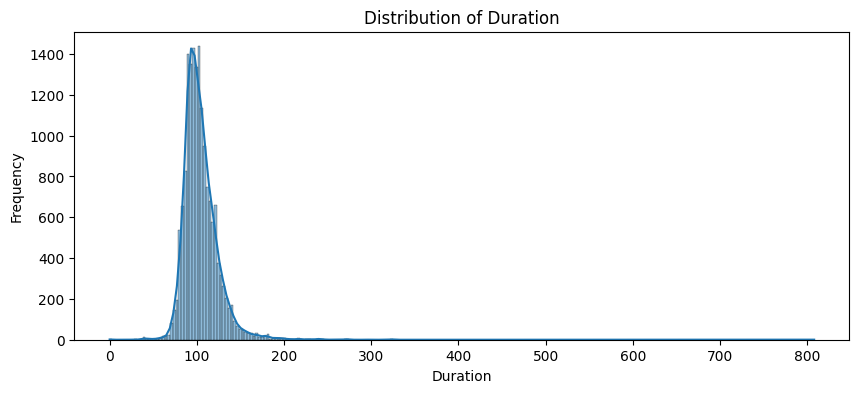

In [132]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["duration"].dropna(), kde=True)
plt.title(f'Distribution of Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

- Gaussian  distribution
- after log transformation the data spans from 3 top 6.5
- sharp spikes in the distribution, could be random noise or systematic as per standard movie release durations

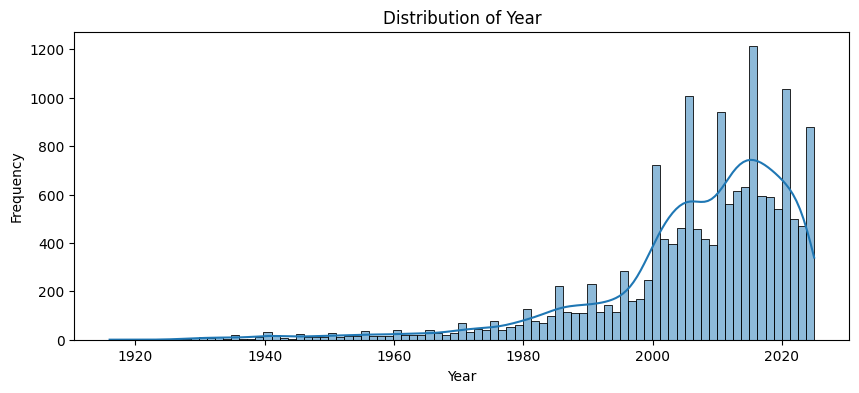

In [133]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["year"].dropna(), kde=True)
plt.title(f'Distribution of Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

- more movies in later years(left skewed), showing an expanding industry
- this will pose a problem: I wanted to split based on release date, this will cause the trainning data to take in more recent movies which may hurt predictability

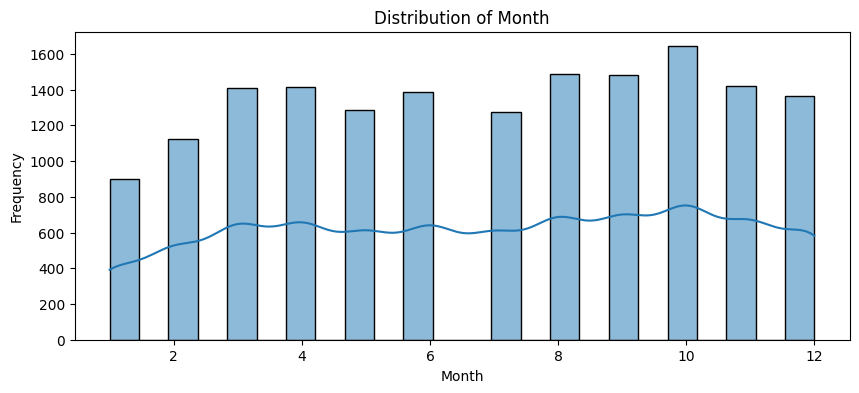

In [134]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["month"].dropna(), kde=True)
plt.title(f'Distribution of Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

- Uniform distribution 


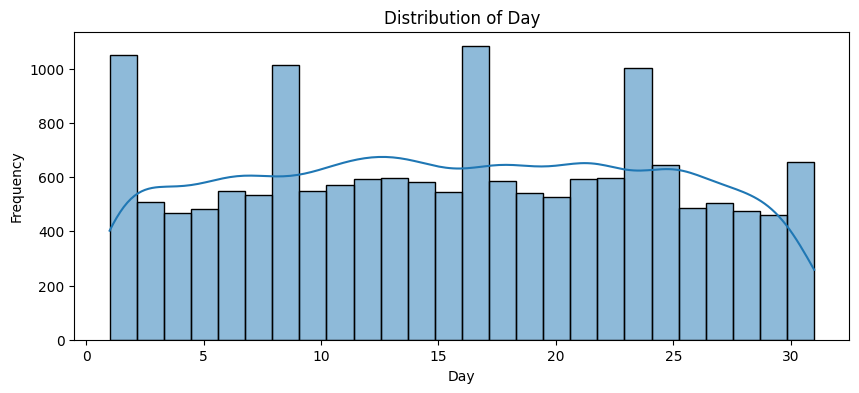

In [135]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["day"].dropna(), kde=True)
plt.title(f'Distribution of Day')
plt.xlabel('Day')
plt.ylabel('Frequency')
plt.show()

- Uniform distribution
- traces of seasonality every weekend

In [136]:
plt.figure(figsize=(10, 4))
fig = px.histogram(df_num["metascore"], nbins=150, title="Distribution of Metascore")
fig.update_xaxes(
    tickmode='linear',     # Linear tick spacing
    dtick=5,               # Tick every 10 units
    title='X Axis Label'
)



fig.update_traces(
    marker_line_width=1,
    marker_line_color="black"
)
fig.show()


<Figure size 1000x400 with 0 Axes>

- Left skewed
- Gaussian distribution
- concentration around the cutoff(70) which may cause imprecision in decisions

### Bivariate

In [137]:
for col in df_cat.columns:
    table = pd.crosstab(df_cat[col], df_num["is_good"], normalize='index') * 100
    table.rename(columns={0: 'Not Good', 1: 'Good'}, index={0: col, 1: col}, inplace=True)
    table = table.round(2)
    table["total"] = df_cat[col].value_counts()
    table["difference from mean"] = table["Good"] - df_num["is_good"].mean() * 100
    print("="*50)
    print(table)
    print("=" *50)
    print(df_cat[col].value_counts())
    print("="*50)

is_good   Not Good   Good  total  difference from mean
rating                                                
Approved    100.00   0.00      1            -12.508431
G            76.92  23.08    299             10.571569
NC-17        90.32   9.68     31             -2.828431
PG           88.35  11.65   1700             -0.858431
PG-13        92.89   7.11   2966             -5.398431
R            90.19   9.81   5941             -2.698431
TV-14        77.16  22.84    232             10.331569
TV-G         64.79  35.21     71             22.701569
TV-MA        85.47  14.53    406              2.021569
TV-PG        60.49  39.51    243             27.001569
TV-Y        100.00   0.00      2            -12.508431
TV-Y7        60.00  40.00      5             27.491569
X           100.00   0.00      3            -12.508431
rating
R           5941
PG-13       2966
PG          1700
TV-MA        406
G            299
TV-PG        243
TV-14        232
TV-G          71
NC-17         31
TV-Y7          

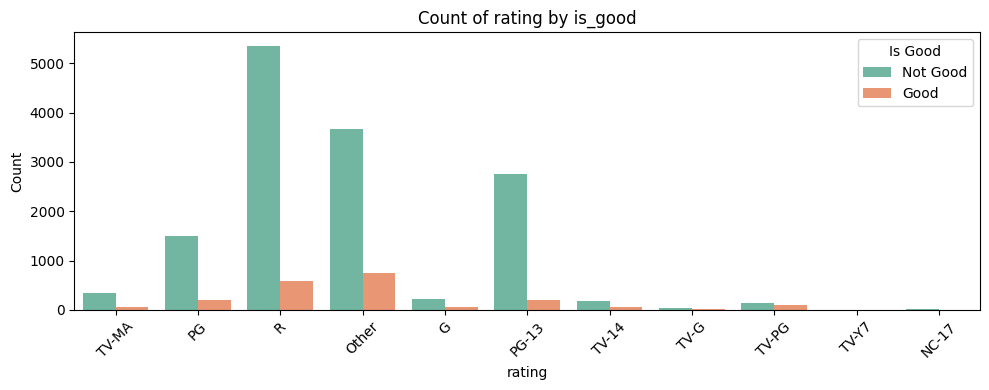

C:\Users\mosta\AppData\Local\Temp\ipykernel_22024\3813147861.py:11: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



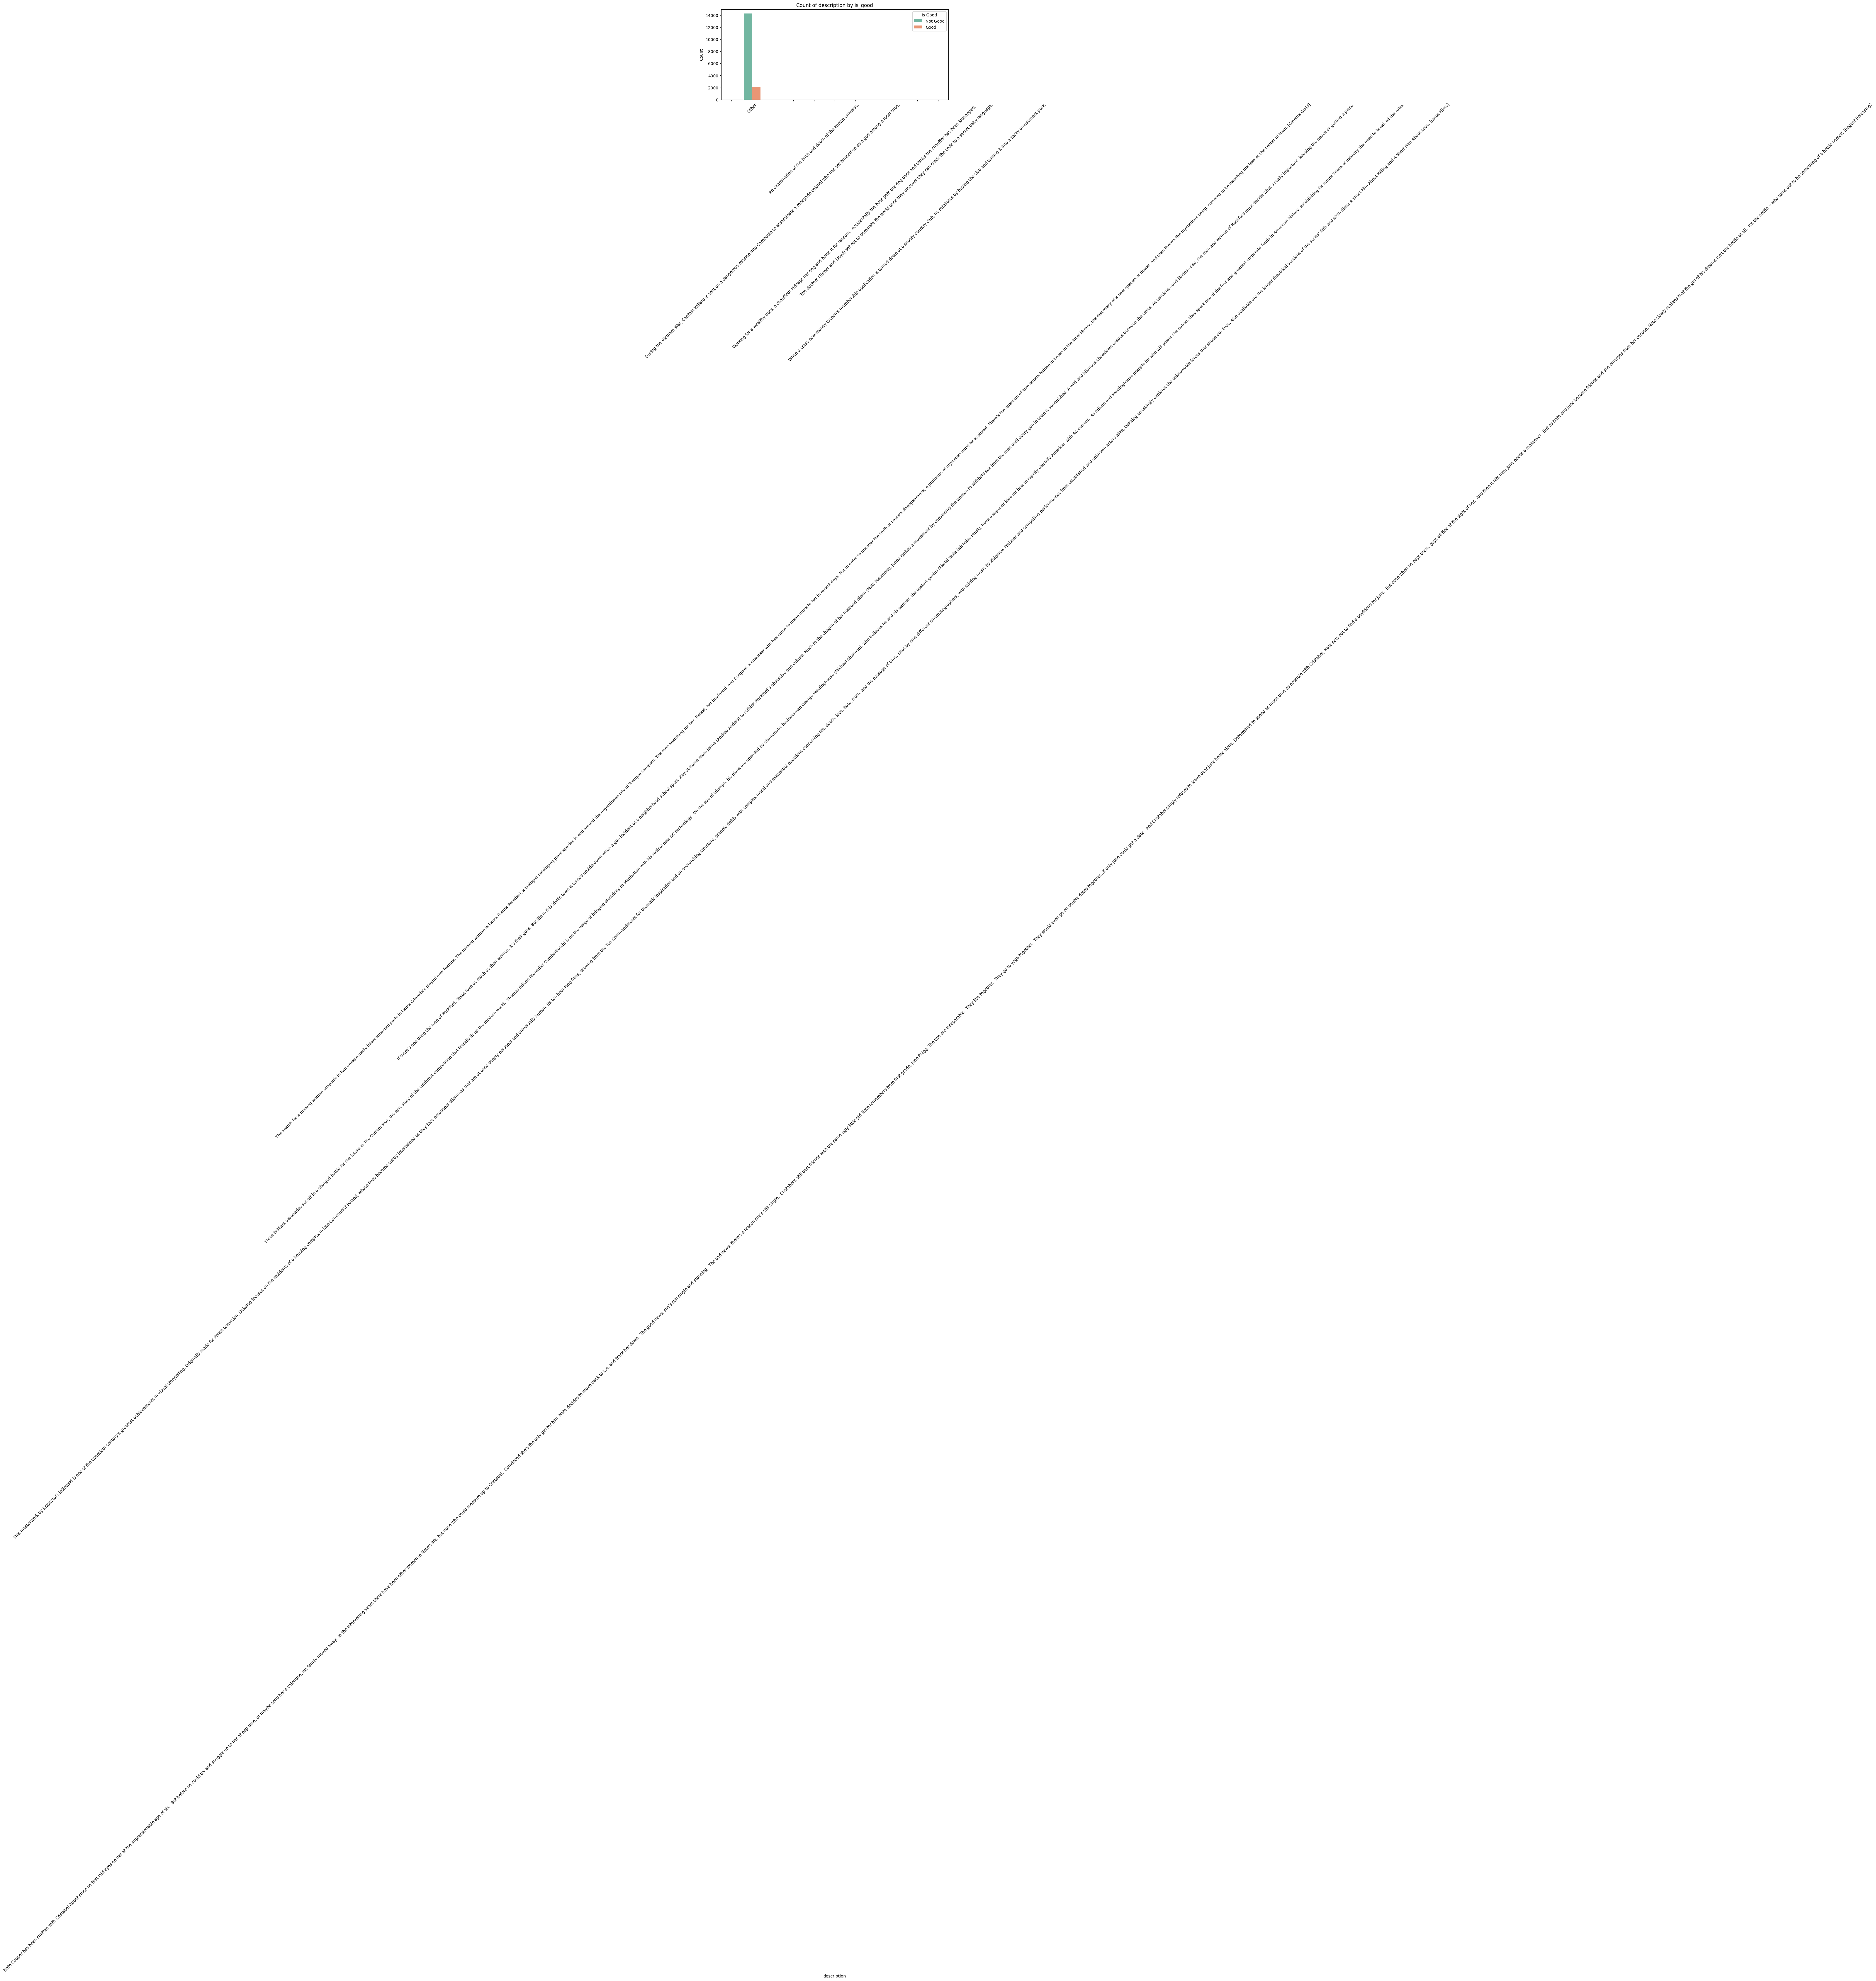

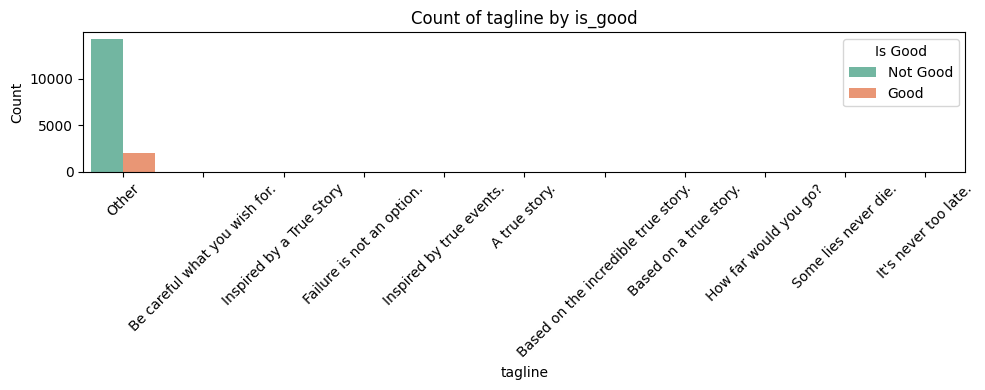

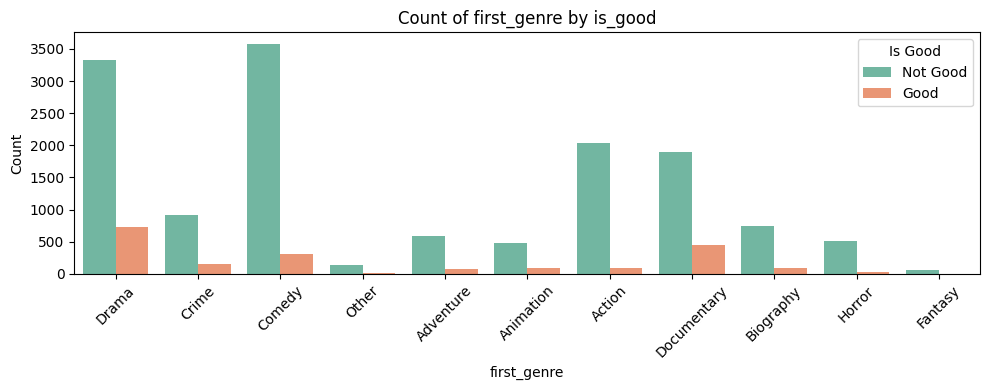

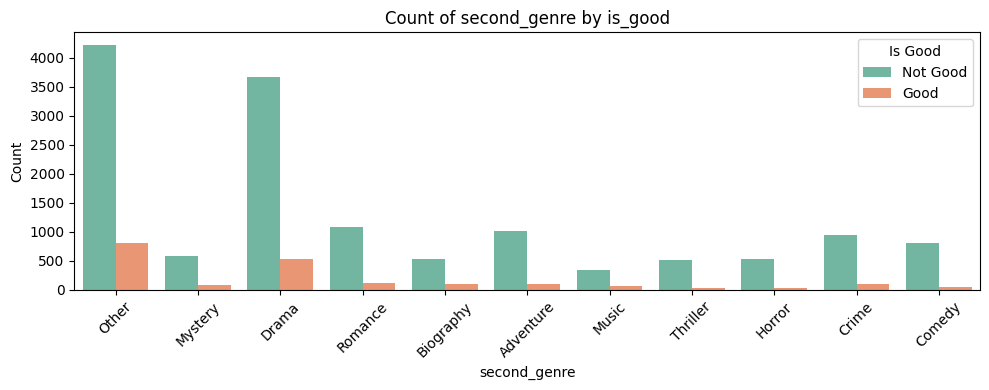

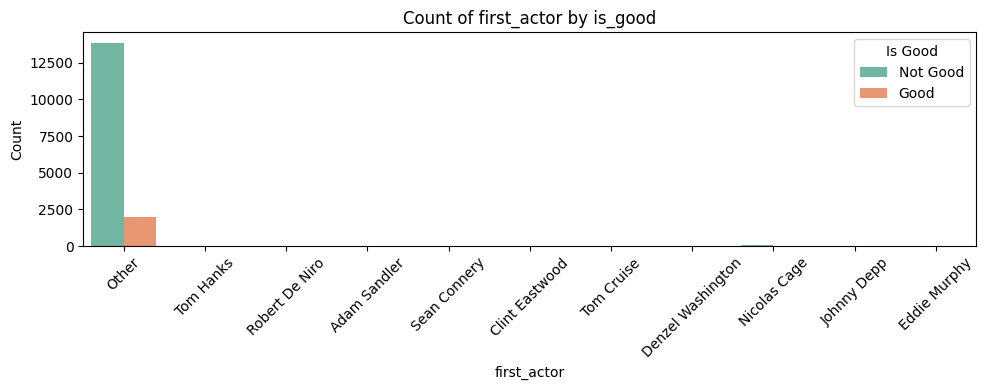

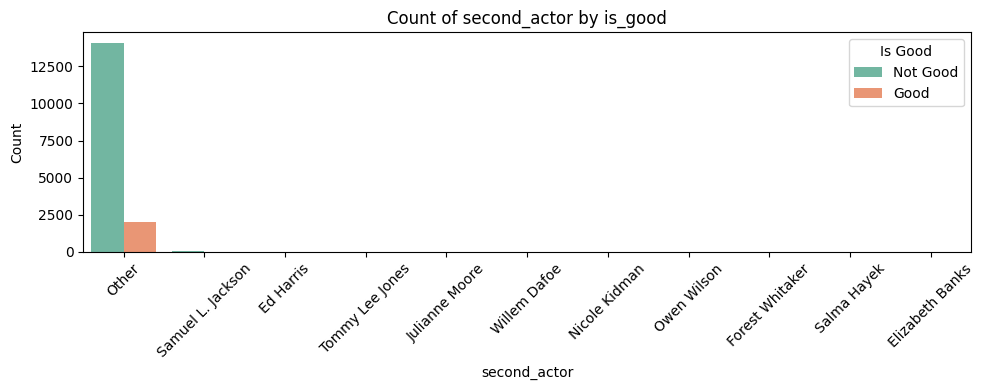

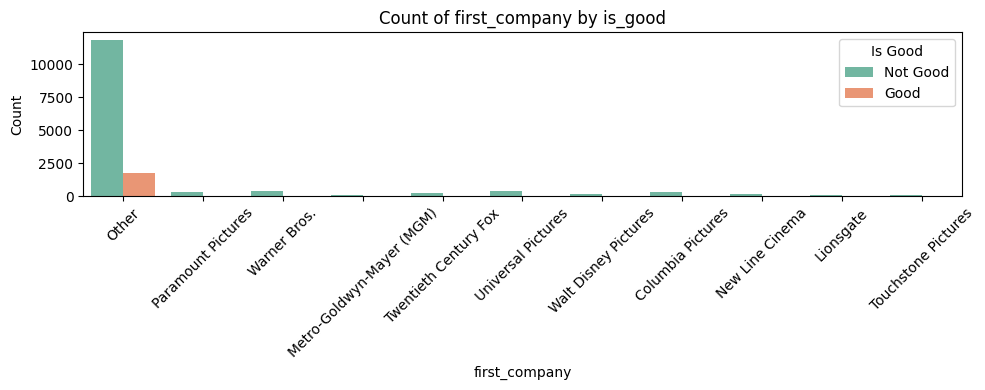

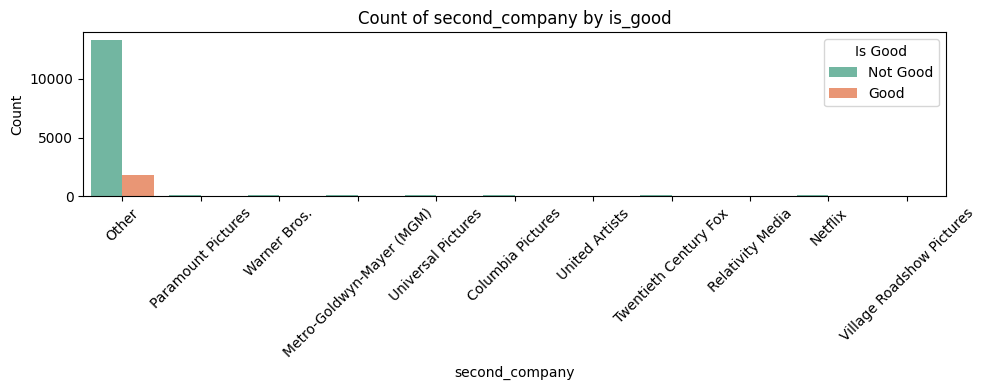

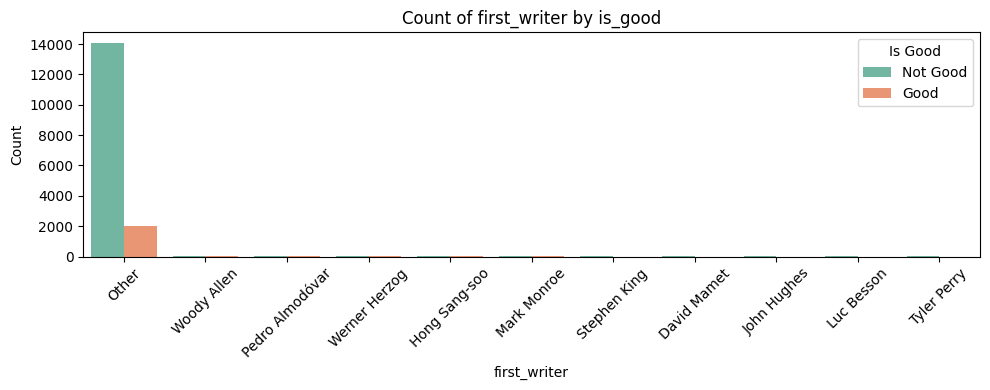

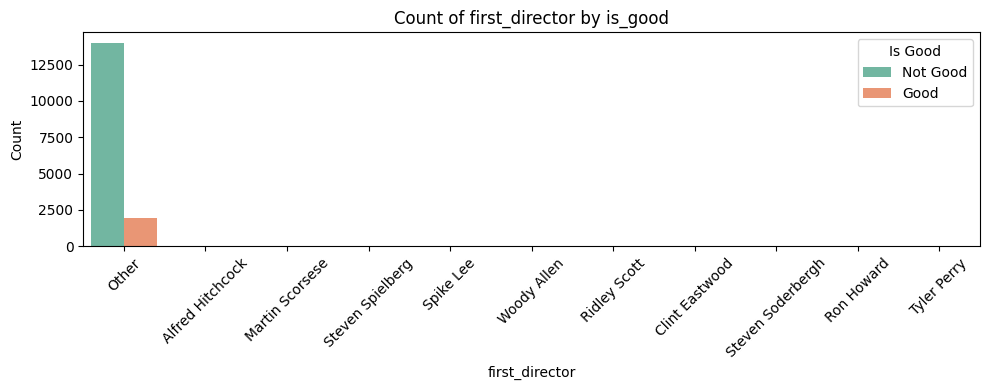

In [138]:
for col in df_cat.columns:
    if df_vis[col].nunique() > 10:
        df_vis[col] = df_vis[col].apply(lambda x: x if x in df_vis[col].value_counts().nlargest(10).index else 'Other')
        plt.figure(figsize=(10, 4))
        sns.countplot(data=df_vis, x=col, hue="is_good", palette="Set2")
        plt.title(f'Count of {col} by is_good')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.legend(title='Is Good', loc='upper right', labels=['Not Good', 'Good'])
        plt.tight_layout()
        plt.show()

In [139]:
signficant_featrures = []
for col in df_cat.columns:
    observed = pd.crosstab(df_cat[col], df_num["is_good"])
    print(f"Chi-square test for {col}:")
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)
    print("=" * 50)
    print(f"Chi-square test for {col}:")
    print("-" * 50)
    print(f"  Chi-square statistic: {chi2_stat}")
    print("-"*50)
    print(f"  Degrees of freedom: {dof}")
    print("-"*50)
    print(f"  P-value: {p_value}")
    print("="*50)
    if p_value < 0.05:
        print(f"  Result: Reject the null hypothesis. There is a significant association between {col} and is_good.")
        signficant_featrures.append(col)
    else:
        print(f"  Result: Fail to reject the null hypothesis. There is no significant association between {col} and is_good.")

print("\nSignificant features based on Chi-square test:")
print(signficant_featrures)


Chi-square test for rating:
Chi-square test for rating:
--------------------------------------------------
  Chi-square statistic: 389.821706560077
--------------------------------------------------
  Degrees of freedom: 12
--------------------------------------------------
  P-value: 5.4015387872533034e-76
  Result: Reject the null hypothesis. There is a significant association between rating and is_good.
Chi-square test for description:
Chi-square test for description:
--------------------------------------------------
  Chi-square statistic: 16308.999999999996
--------------------------------------------------
  Degrees of freedom: 16304
--------------------------------------------------
  P-value: 0.4874840428473285
  Result: Fail to reject the null hypothesis. There is no significant association between description and is_good.
Chi-square test for tagline:
Chi-square test for tagline:
--------------------------------------------------
  Chi-square statistic: 11503.908941562802
---

In [140]:
df_num.dropna(inplace=True)
df_num.drop(columns=["metascore"], inplace=True)

In [141]:
for col in df_num.columns:
    if col != "is_good":
        table = df_num.groupby("is_good")[col].agg(["mean", "median", "std", "min", "max"])
        print("="*50)
        print(f"Descriptive statistics for {col} by is_good:")
        print(table)
        print("="*50)

Descriptive statistics for duration by is_good:
               mean  median        std  min  max
is_good                                         
0        103.196290   100.0  18.732550    0  808
1        112.690523   106.0  34.204591   30  729
Descriptive statistics for year by is_good:
                mean  median        std   min   max
is_good                                            
0        2007.402102  2011.0  14.053492  1927  2025
1        2002.035538  2011.0  23.540115  1916  2025
Descriptive statistics for month by is_good:
             mean  median       std  min  max
is_good                                      
0        6.737481     7.0  3.321151    1   12
1        7.370681     8.0  3.429186    1   12
Descriptive statistics for day by is_good:
              mean  median       std  min  max
is_good                                       
0        15.635068    16.0  8.577263    1   31
1        15.622409    16.0  8.590093    1   31
Descriptive statistics for n_genres by is_go

C:\Users\mosta\AppData\Local\Temp\ipykernel_22024\2371499515.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




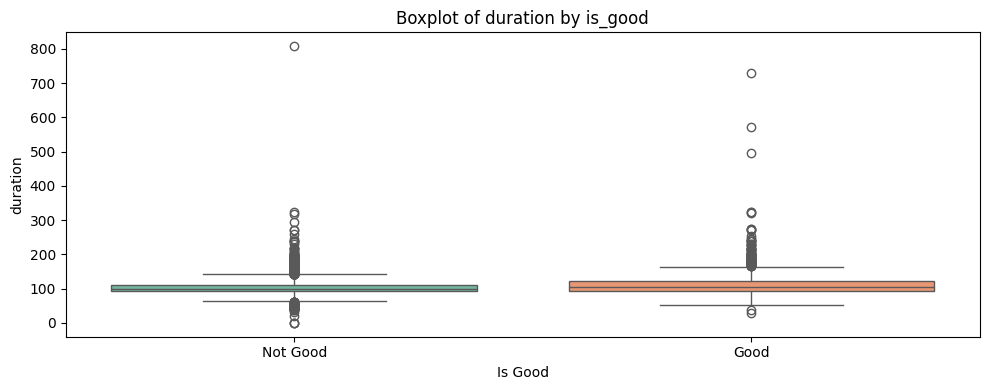

C:\Users\mosta\AppData\Local\Temp\ipykernel_22024\2371499515.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




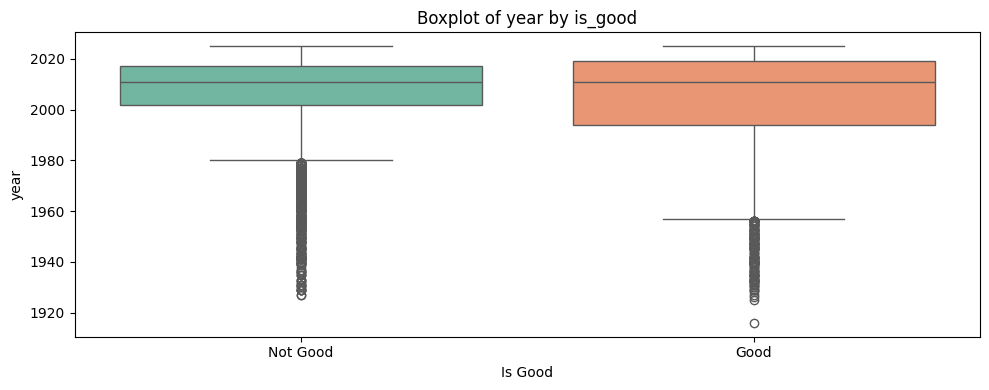

C:\Users\mosta\AppData\Local\Temp\ipykernel_22024\2371499515.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




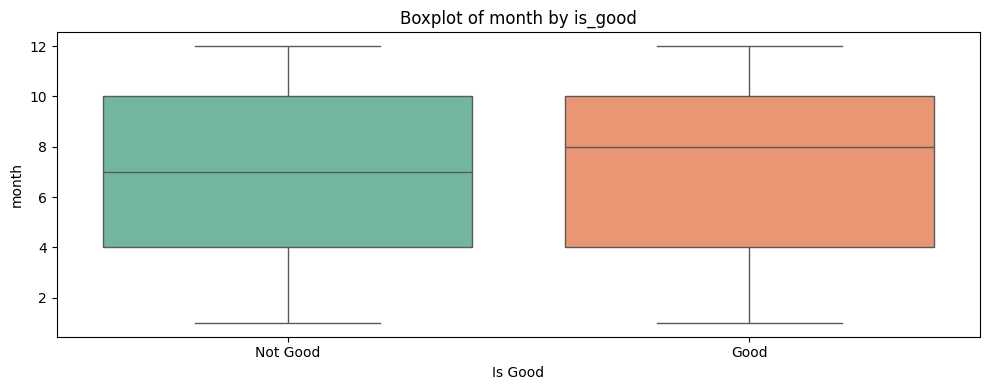

C:\Users\mosta\AppData\Local\Temp\ipykernel_22024\2371499515.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




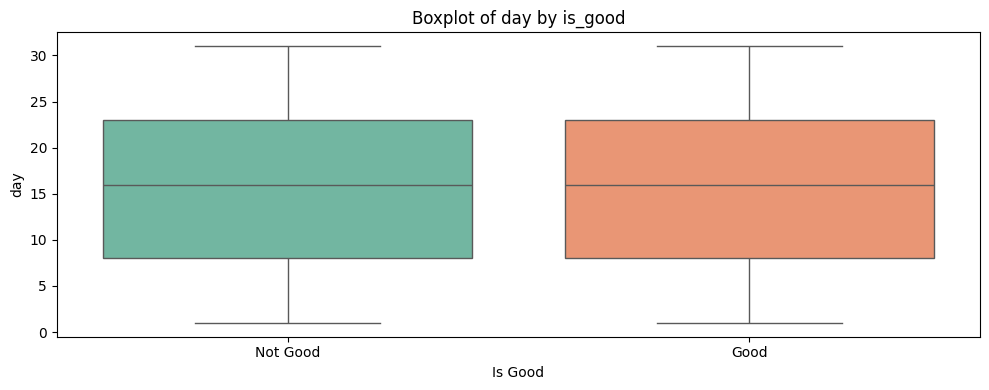

C:\Users\mosta\AppData\Local\Temp\ipykernel_22024\2371499515.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




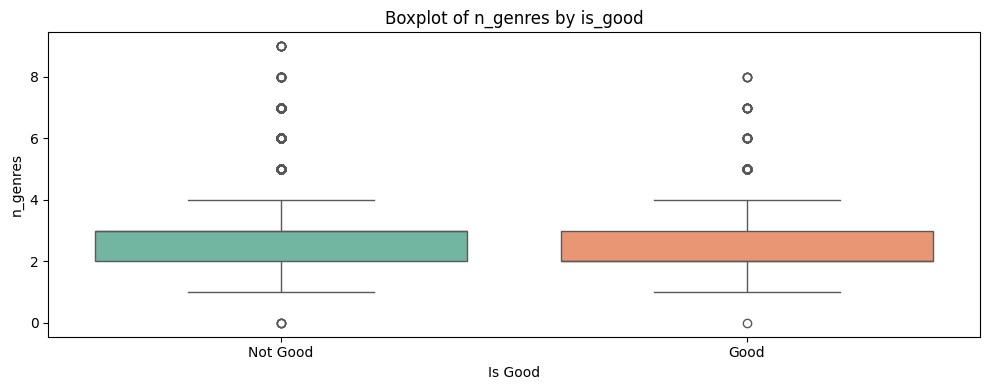

In [142]:
for col in df_num.columns:
    if col != "is_good":
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df_num, x="is_good", y=col, palette="Set2")
        plt.title(f'Boxplot of {col} by is_good')
        plt.xlabel('Is Good')
        plt.ylabel(col)
        plt.xticks([0, 1], ['Not Good', 'Good'])
        plt.tight_layout()
        plt.show()

In [143]:
for col in df_num.columns:
    if col != "is_good":
        table = df_num.groupby("is_good")[col].agg(["mean", "median"])
        table["mean_diff"] = table["mean"] - df_num[col].mean()
        table["median_diff"] = table["median"] - df_num[col].median()
        print("="*50)
        print(f"Mean difference for {col} by is_good:")
        print(table["mean_diff"])
        print("="*50)
        print(f"Median difference for {col} by is_good:")
        print(table["median_diff"])
        print("="*50)


Mean difference for duration by is_good:
is_good
0   -1.187072
1    8.307161
Name: mean_diff, dtype: float64
Median difference for duration by is_good:
is_good
0   -1.0
1    5.0
Name: median_diff, dtype: float64
Mean difference for year by is_good:
is_good
0    0.670986
1   -4.695578
Name: mean_diff, dtype: Float64
Median difference for year by is_good:
is_good
0    0.0
1    0.0
Name: median_diff, dtype: Float64
Mean difference for month by is_good:
is_good
0    -0.07917
1    0.554031
Name: mean_diff, dtype: Float64
Median difference for month by is_good:
is_good
0    0.0
1    1.0
Name: median_diff, dtype: Float64
Mean difference for day by is_good:
is_good
0    0.001583
1   -0.011077
Name: mean_diff, dtype: Float64
Median difference for day by is_good:
is_good
0    0.0
1    0.0
Name: median_diff, dtype: Float64
Mean difference for n_genres by is_good:
is_good
0    0.033695
1   -0.235800
Name: mean_diff, dtype: float64
Median difference for n_genres by is_good:
is_good
0    0.0
1   -1.

### Multivariate

In [144]:
le = LabelEncoder()
df_heat_cat = df_cat.copy()
for col in df_heat_cat.columns:
    df_heat_cat[col] = le.fit_transform(df_heat_cat[col].astype(str))
df_heat = pd.concat([df_heat_cat, df_num], axis=1)

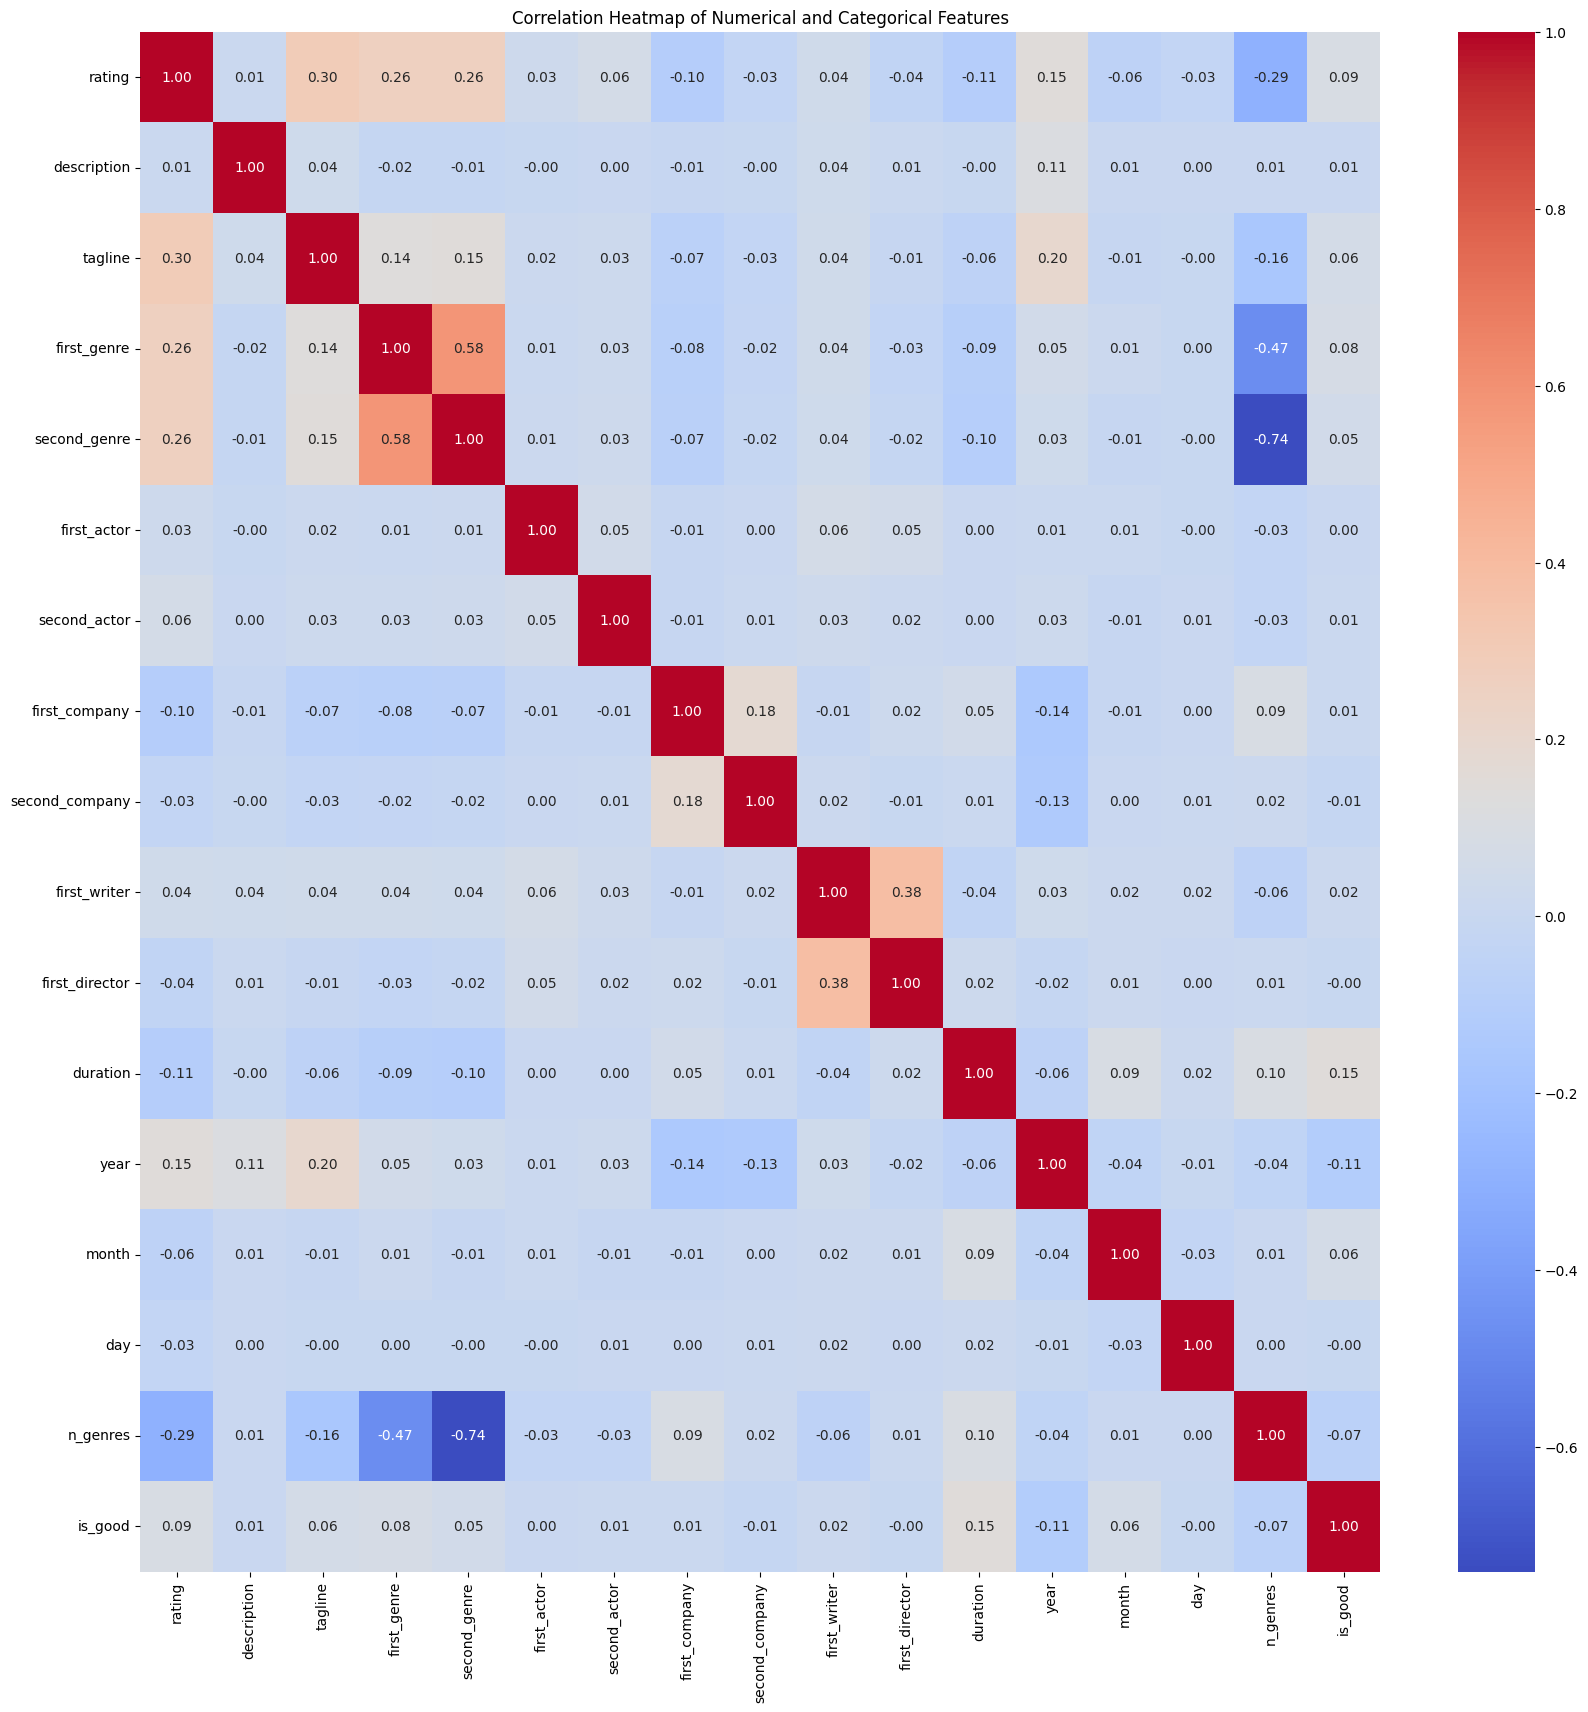

In [145]:
plt.figure(figsize=(20, 20)) 
fig = sns.heatmap(df_heat.corr(), annot=True, cmap='coolwarm', fmt=".2f")
fig.set_title('Correlation Heatmap of Numerical and Categorical Features')
plt.show()

Most important features are duration, rating, genres, second genre.

### Data Split

In [146]:
x = df.drop(columns=['is_good', "metascore"])
y = df['is_good']

In [147]:
from sklearn.model_selection import TimeSeriesSplit

In [148]:
def train_val_test_time_split(X, y, date_column, train_size=0.8, val_size=0.1, test_size=0.1):
    """
    Create chronological train/validation/test splits from X and y
    
    Args:
        X: Features DataFrame
        y: Target Series/DataFrame
        date_column: Column in X containing release dates/years
        train_size: Proportion for training (oldest)
        val_size: Proportion for validation (middle)
        test_size: Proportion for testing (newest)
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-10, "Sizes must sum to 1"
    
    # Combine X and y temporarily
    df = X.copy()
    df['target'] = y
    
    # Sort by date
    df_sorted = df.sort_values(date_column).reset_index(drop=True)
    n = len(df_sorted)
    
    # Calculate split indices
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    # Split
    train_df = df_sorted.iloc[:train_end].copy()
    val_df = df_sorted.iloc[train_end:val_end].copy()
    test_df = df_sorted.iloc[val_end:].copy()
    
    # Separate back into X and y
    x_train = train_df.drop('target', axis=1)
    y_train = train_df['target']
    x_val = val_df.drop('target', axis=1)
    y_val = val_df['target']
    x_test = test_df.drop('target', axis=1)
    y_test = test_df['target']
    
    print(f"Train: {train_df[date_column].min()} to {train_df[date_column].max()} ({len(train_df)} samples, {train_size*100:.0f}%)")
    print(f"Val:   {val_df[date_column].min()} to {val_df[date_column].max()} ({len(val_df)} samples, {val_size*100:.0f}%)")
    print(f"Test:  {test_df[date_column].min()} to {test_df[date_column].max()} ({len(test_df)} samples, {test_size*100:.0f}%)")
    
    return x_train, x_val, x_test, y_train, y_val, y_test

x_train, x_val, x_test, y_train, y_val, y_test = train_val_test_time_split(x, y, date_column='year')

Train: 1916 to 2019 (13047 samples, 80%)
Val:   2019 to 2022 (1631 samples, 10%)
Test:  2022 to 2025 (1631 samples, 10%)


### ML

In [151]:
categorical_features = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [163]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('encoder', TargetEncoder(smoothing=10)),
            ('imputer', KNNImputer(n_neighbors=5))
        ]), categorical_features),
        
        ('num', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numerical_features)
    ]
)
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', XGBClassifier())
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)


print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

Training Accuracy: 1.00
Training Precision: 1.00
Training Recall: 1.00
Training F1 Score: 1.00
Validation Accuracy: 0.85
Validation Precision: 0.00
Validation Recall: 0.00
Validation F1 Score: 0.00


c:\Users\mosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



In [159]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('encoder', TargetEncoder(smoothing=10)),
            ('imputer', KNNImputer(n_neighbors=5))
        ]), categorical_features),
        
        ('num', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numerical_features)
    ]
)
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', DummyClassifier(strategy='stratified', random_state=42))
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)


print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

Training Accuracy: 0.49
Training Precision: 0.12
Training Recall: 0.50
Training F1 Score: 0.19
Validation Accuracy: 0.50
Validation Precision: 0.15
Validation Recall: 0.48
Validation F1 Score: 0.23


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('encoder', TargetEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ('imputer', KNNImputer(n_neighbors=5))
        ]), categorical_features),
        
        ('num', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numerical_features)
    ]
)
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', LogisticRegression())
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)


print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

c:\Users\mosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Training Accuracy: 0.58
Training Precision: 0.17
Training Recall: 0.63
Training F1 Score: 0.26
Validation Accuracy: 0.58
Validation Precision: 0.21
Validation Recall: 0.64
Validation F1 Score: 0.31


In [ ]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

Training Accuracy: 1.00
Training Precision: 1.00
Training Recall: 1.00
Training F1 Score: 1.00
Validation Accuracy: 0.65
Validation Precision: 0.19
Validation Recall: 0.41
Validation F1 Score: 0.26


In [ ]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

Training Accuracy: 1.00
Training Precision: 1.00
Training Recall: 1.00
Training F1 Score: 1.00
Validation Accuracy: 0.85
Validation Precision: 0.50
Validation Recall: 0.04
Validation F1 Score: 0.07


In [ ]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', GaussianNB())
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

Training Accuracy: 0.78
Training Precision: 0.26
Training Recall: 0.45
Training F1 Score: 0.33
Validation Accuracy: 0.76
Validation Precision: 0.28
Validation Recall: 0.37
Validation F1 Score: 0.32


In [ ]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', SVC())
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1 Score: {train_f1:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Precision: {val_precision:.2f}")
print(f"Validation Recall: {val_recall:.2f}")
print(f"Validation F1 Score: {val_f1:.2f}")

Training Accuracy: 0.50
Training Precision: 0.15
Training Recall: 0.68
Training F1 Score: 0.24
Validation Accuracy: 0.63
Validation Precision: 0.14
Validation Recall: 0.27
Validation F1 Score: 0.18


### Model tunning

In [168]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, class_weight='balanced'))
])

# Define parameter grid for the pipeline
# Use 'model__' prefix to access model parameters
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [1000, 2000]
}

# Create GridSearchCV that wraps the entire pipeline
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(x_train, y_train) 

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(x_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, best_model.predict(x_train))
train_precision = precision_score(y_train, best_model.predict(x_train))
train_recall = recall_score(y_train, best_model.predict(x_train))
train_f1 = f1_score(y_train, best_model.predict(x_train))

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("=== Best Parameters ===")
print(grid_search.best_params_)
print(f"\nBest CV Score (AUC): {grid_search.best_score_:.4f}")
print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall: {train_recall:.4f}")
print(f"Training F1 Score: {train_f1:.4f}")
print("\n=== Test Metrics ===")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

=== Best Parameters ===
{'model__C': 0.1, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'saga'}

Best CV Score (AUC): 0.7354

=== Training Metrics ===
Training Accuracy: 0.9963
Training Precision: 0.9697
Training Recall: 1.0000
Training F1 Score: 0.9846

=== Test Metrics ===
Test Accuracy: 0.8461
Test Precision: 0.5532
Test Recall: 0.1016
Test F1 Score: 0.1716


In [173]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ('model', LogisticRegression( 
        random_state=42,
        C=0.1,
        class_weight=None,
        max_iter=1000,
        penalty='l2',
        solver='saga'
        ))
])


pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_val)
train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
train_precision = precision_score(y_train, pipeline.predict(x_train))
train_recall = recall_score(y_train, pipeline.predict(x_train))
train_f1 = f1_score(y_train, pipeline.predict(x_train))
test_accuracy = accuracy_score(y_val, y_pred)
test_precision = precision_score(y_val, y_pred)
test_recall = recall_score(y_val, y_pred)
test_f1 = f1_score(y_val, y_pred)


print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall: {train_recall:.4f}")
print(f"Training F1 Score: {train_f1:.4f}")
print("\n=== Test Metrics ===")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}") 


=== Training Metrics ===
Training Accuracy: 0.9963
Training Precision: 0.9697
Training Recall: 1.0000
Training F1 Score: 0.9846

=== Test Metrics ===
Test Accuracy: 0.8461
Test Precision: 0.4865
Test Recall: 0.0720
Test F1 Score: 0.1254


### Model evaluation: Top k-movies

In [174]:
test_prob = pipeline.predict_proba(x_test)[:, 1]
test_pred = pipeline.predict(x_test)

print("=== Test Metrics ===")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_prob):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, test_pred, zero_division=0):.4f}")
print()
print(classification_report(y_test, test_pred, zero_division=0))

=== Test Metrics ===
ROC-AUC:   0.7476
Accuracy:  0.8461
Precision: 0.5532
Recall:    0.1016
F1:        0.1716

              precision    recall  f1-score   support

           0       0.85      0.98      0.92      1375
           1       0.55      0.10      0.17       256

    accuracy                           0.85      1631
   macro avg       0.70      0.54      0.54      1631
weighted avg       0.81      0.85      0.80      1631



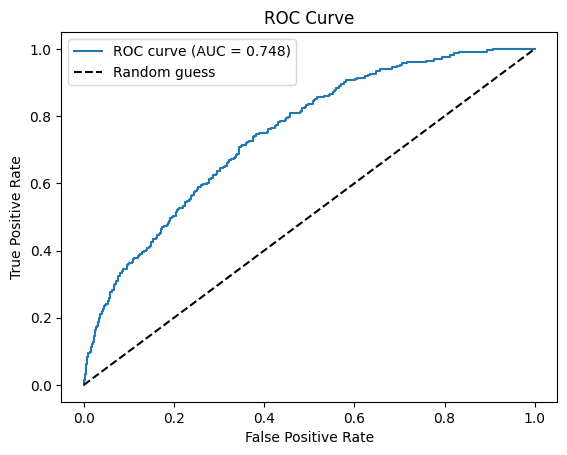

In [175]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve')
plt.legend()
plt.show()

In [176]:
def evaluate_top_k(y_true, y_prob, k_percent=0.2):
    # Convert to DataFrame for easier handling
    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    })

    # Sort by predicted probability descending
    df_sorted = df.sort_values(by="y_prob", ascending=False)

    # Determine K
    K = int(len(df_sorted) * k_percent)

    # Select top K
    top_k = df_sorted.iloc[:K]

    # Compute metrics
    true_positives_in_top_k = top_k["y_true"].sum()
    total_positives = df["y_true"].sum()
    baseline_rate = total_positives / len(df)

    precision_at_k = true_positives_in_top_k / K
    recall_at_k = true_positives_in_top_k / total_positives
    lift = precision_at_k / baseline_rate

    return {
        "K": K,
        "Precision_K": precision_at_k,
        "Recall_K": recall_at_k,
        "Lift": lift,
        "Baseline Positive Rate": baseline_rate
    }

# Get predicted probabilities for class 1
y_prob = pipeline.predict_proba(x_test)[:, 1]

for k in [0.1, 0.2, 0.3, 0.4]:
    results = evaluate_top_k(y_test, y_prob, k_percent=k)
    print(f"\nTop {int(k*100)}%")
    print(results)


Top 10%
{'K': 163, 'Precision_K': np.float64(0.44171779141104295), 'Recall_K': np.float64(0.28125), 'Lift': np.float64(2.8142254601226995), 'Baseline Positive Rate': np.float64(0.15695892090741875)}

Top 20%
{'K': 326, 'Precision_K': np.float64(0.34049079754601225), 'Recall_K': np.float64(0.43359375), 'Lift': np.float64(2.169298792177914), 'Baseline Positive Rate': np.float64(0.15695892090741875)}

Top 30%
{'K': 489, 'Precision_K': np.float64(0.30265848670756645), 'Recall_K': np.float64(0.578125), 'Lift': np.float64(1.9282655930470347), 'Baseline Positive Rate': np.float64(0.15695892090741875)}

Top 40%
{'K': 652, 'Precision_K': np.float64(0.2745398773006135), 'Recall_K': np.float64(0.69921875), 'Lift': np.float64(1.7491192963957058), 'Baseline Positive Rate': np.float64(0.15695892090741875)}
